In [1]:
%matplotlib inline

import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE" # tells OpenMP to not complain if it notices that two copies of OpenMP are loaded.

In [2]:
import sys

sys.path.append('../../../../')

from computer_vision.misc import download_image_to_numpy

In [3]:
from pathlib import Path
import torch
import numpy as np

import matplotlib.pyplot as plt
from matplotlib import patches
cmap = plt.get_cmap('tab10', 10)
plt.rcParams['savefig.bbox']='tight'

from torchvision.transforms import v2
from torchvision.io import decode_image

torch.manual_seed(1)

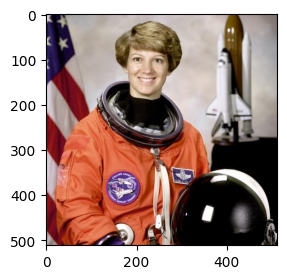

In [4]:
url='https://raw.githubusercontent.com/pytorch/vision/main/gallery/assets/astronaut.jpg'
img= download_image_to_numpy(url)
_, ax=plt.subplots(figsize=(3,3))
ax.imshow(img)

In [5]:
print(f'{type(img)=}, {img.dtype=}, {img.shape=}')
img=torch.from_numpy(img).permute(2,0,1).contiguous() # (H,W,C) to (C,H,W)
print(f'{type(img)=}, {img.dtype=}, {img.shape=}')

type(img)=<class 'numpy.ndarray'>, img.dtype=dtype('uint8'), img.shape=(512, 512, 3)
type(img)=<class 'torch.Tensor'>, img.dtype=torch.uint8, img.shape=torch.Size([3, 512, 512])


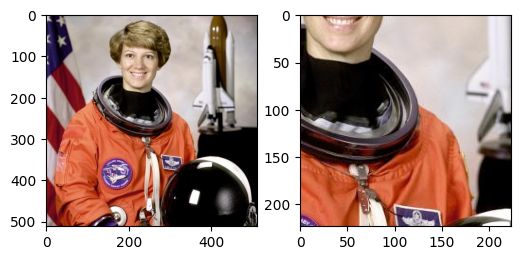

In [6]:
transform=v2.RandomCrop(size=(224, 224))
out=transform(img)
fig, ax=plt.subplots(1,2,figsize=(6,3))
for i, im in enumerate([img, out]): ax[i].imshow(im.permute(1,2,0).contiguous().numpy()) # from (C,H,W) to (H,W,C)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1136.3572].


Scale Dtype -> out0.shape=torch.Size([3, 224, 224]), out0.dtype=torch.float32, range=(0.000, 1.000)
Not-scale Dtype -> out1.shape=torch.Size([3, 224, 224]), out1.dtype=torch.float32, range=(0.000, 255.000)
Scale Dtype + Normalized -> out2.shape=torch.Size([3, 224, 224]), out2.dtype=torch.float32, range=(-2.118, 2.640)
Not-scale Dtype + Normalized -> out3.shape=torch.Size([3, 224, 224]), out3.dtype=torch.float32, range=(-2.118, 1136.357)


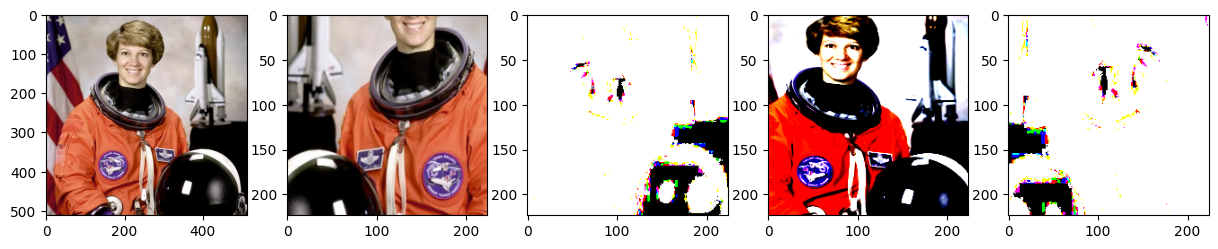

In [7]:
transforms0=v2.Compose([
    v2.RandomResizedCrop(size=(224, 224),antialias=True),
    v2.RandomHorizontalFlip(p=0.5),
    v2.ToDtype(torch.float32, scale=True),
])
out0=transforms0(img)

transforms1=v2.Compose([
    v2.RandomResizedCrop(size=(224, 224),antialias=True),
    v2.RandomHorizontalFlip(p=0.5),
    v2.ToDtype(torch.float32, scale=False),
])
out1=transforms1(img)

transforms2=v2.Compose([
    v2.RandomResizedCrop(size=(224, 224),antialias=True),
    v2.RandomHorizontalFlip(p=0.5),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225]),
])
out2=transforms2(img)

transforms3=v2.Compose([
    v2.RandomResizedCrop(size=(224, 224),antialias=True),
    v2.RandomHorizontalFlip(p=0.5),
    v2.ToDtype(torch.float32, scale=False),
    v2.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225]),
])
out3=transforms3(img)
print(f'Scale Dtype -> {out0.shape=}, {out0.dtype=}, range=({out0.min().item():.3f}, {out0.max().item():.3f})')
print(f'Not-scale Dtype -> {out1.shape=}, {out1.dtype=}, range=({out1.min().item():.3f}, {out1.max().item():.3f})')
print(f'Scale Dtype + Normalized -> {out2.shape=}, {out2.dtype=}, range=({out2.min().item():.3f}, {out2.max().item():.3f})')
print(f'Not-scale Dtype + Normalized -> {out3.shape=}, {out3.dtype=}, range=({out3.min().item():.3f}, {out3.max().item():.3f})')

_, ax=plt.subplots(1, 5, figsize=(15,3))
for i, im in enumerate([img, out0, out1, out2, out3]): ax[i].imshow(im.permute(1,2,0))

keypoints  (6, 2)


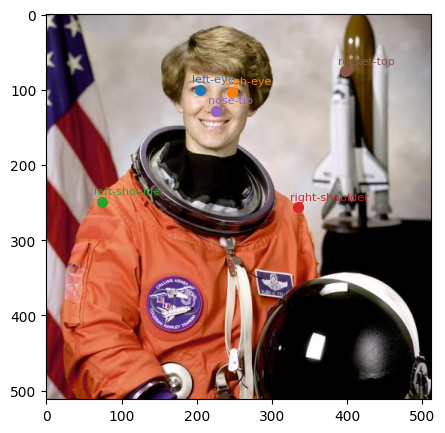

In [8]:
keypoint_names=['left-eye', 'righ-eye','left-shoulder', 'right-shoulder','nose-tip','rocket-top']
keypoints_arr=np.array([[204.1243567753002, 100.05574614065182],
                   [247.15694682675814, 102.69039451114924],
                    [73.27015437392797, 249.352487135506],
                   [334.1003430531733, 256.37821612349916],
                   [225.2015437392796, 128.15866209262435],
                   [397.3319039451115, 75.4656946826758]])
# tv_tensor Keypoints does not support keypoints of 3 dim, i.e., not support visibility
# keypoints_arr=np.hstack((keypoints_arr, 
#            np.ones((keypoints_arr.shape[0],1), dtype=keypoints_arr.dtype))) # (x, y, visibility)
print('keypoints ', keypoints_arr.shape)
_, ax=plt.subplots(figsize=(5,5))
ax.imshow(img.permute(1,2,0))
for j, (point, name) in enumerate(zip(keypoints_arr, keypoint_names)):
    if len(point)>2 and point[2]==0: continue
    ax.scatter(point[0], point[1], marker="o", color=cmap(j), s=50)
    ax.text(*(point[:2]-10), f'{name}', color=cmap(j), fontsize=8)

In [9]:
from torchvision import tv_tensors 

boxes=tv_tensors.BoundingBoxes(
    [
     [15,10,370,510],
    [275, 340, 510, 510],
    [130, 345, 210, 425],
    ],
    format="XYXY", canvas_size=img.shape[-2:])

keypoints=tv_tensors.KeyPoints(keypoints_arr, canvas_size=img.shape[-2:])

transforms=v2.Compose([
    v2.RandomResizedCrop(size=(224,224),antialias=True),
    v2.RandomPhotometricDistort(p=1),
    v2.RandomHorizontalFlip(p=1)
])
out_img, out_boxes, out_keypoints=transforms(img, boxes, keypoints)
print(type(boxes), type(out_boxes))
print(type(keypoints), type(out_keypoints), out_keypoints.shape)

<class 'torchvision.tv_tensors._bounding_boxes.BoundingBoxes'> <class 'torchvision.tv_tensors._bounding_boxes.BoundingBoxes'>
<class 'torchvision.tv_tensors._keypoints.KeyPoints'> <class 'torchvision.tv_tensors._keypoints.KeyPoints'> torch.Size([6, 2])


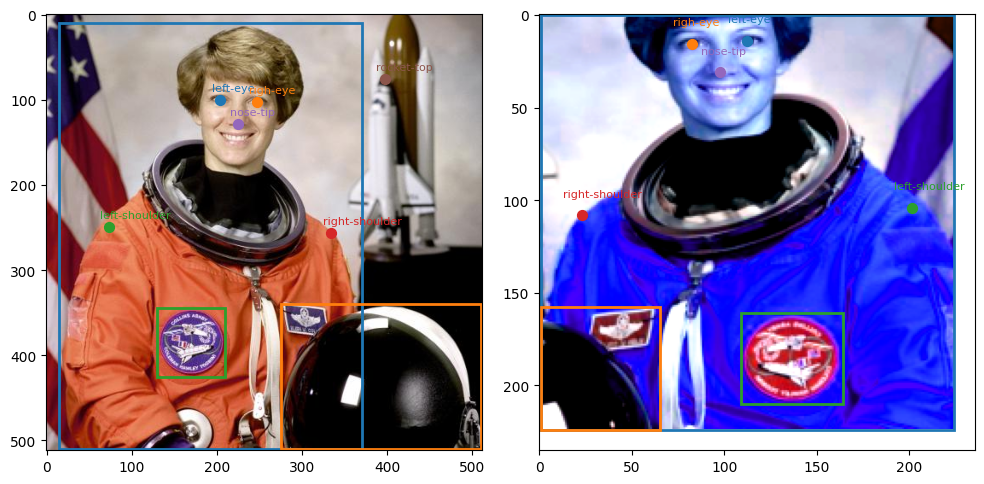

In [10]:
_, ax=plt.subplots(1,2,figsize=(10,5))
for i, (im, box, kpts) in enumerate(zip([img, out_img],[boxes, out_boxes],[keypoints, out_keypoints])):
    ax[i].imshow(im.permute(1,2,0)) # (C,H,W) to (H,W,C)
    for j, bb in enumerate(box):
        # Create a Rectangle patch
        rect = patches.Rectangle(bb[:2], bb[2]-bb[0], bb[3]-bb[1], linewidth=2, edgecolor=cmap(j), facecolor='none')
        # Add the patch to the Axes
        ax[i].add_patch(rect)

    # Filter only keypoints inside image
    height, width=im.shape[-2:]
    inside=torch.logical_and(kpts[...,0]>=0, kpts[...,0]<width) & torch.logical_and(kpts[...,1]>=0, kpts[...,1]<height)
    kpts=kpts[inside]
    for j, (point, name) in enumerate(zip(kpts, keypoint_names)):
        ax[i].scatter(point[0], point[1], marker="o", color=cmap(j), s=50)
        ax[i].text(*(point-10), f'{name}', color=cmap(j), fontsize=8)
plt.tight_layout()

In [11]:
img_dp=tv_tensors.Image(torch.randint(0,256,(3,256,256),dtype=torch.uint8))
print(f"{isinstance(img_dp, torch.Tensor)=}")
print(f"{img_dp.dtype=}, {img_dp.shape=}, {img_dp.sum()=}")

isinstance(img_dp, torch.Tensor)=True
img_dp.dtype=torch.uint8, img_dp.shape=torch.Size([3, 256, 256]), img_dp.sum()=tensor(25087318)


('arbitrary', {'structure': '!'})


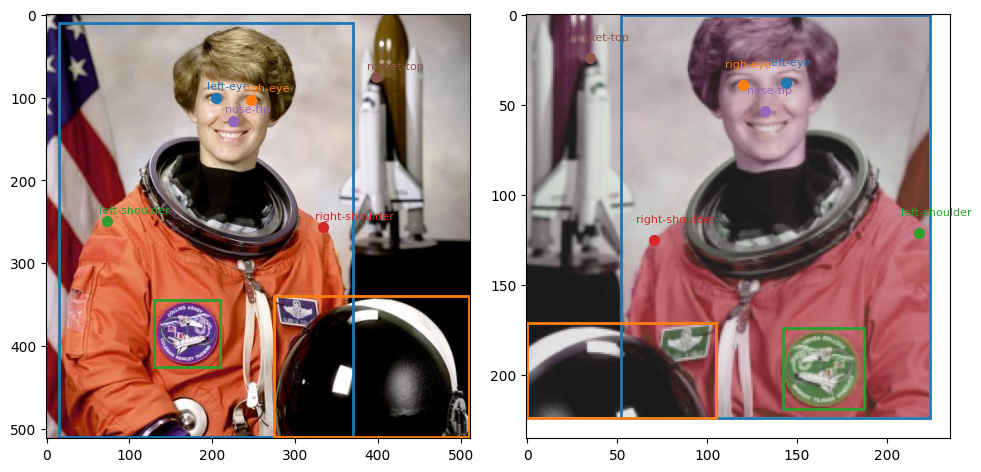

In [15]:
target={
    "boxes":boxes,
    "keypoints":keypoints,
    "labels":torch.arange(boxes.shape[0]),
    "this_is_ignored":("arbitrary",{"structure":"!"}),
}
# Re-using the transforms and definitions from above
out_img, out_target=transforms(img, target)

_, ax=plt.subplots(1,2,figsize=(10,5))
for i, (im, box, kpts) in enumerate(zip([img, out_img],[target['boxes'], out_target["boxes"]],[target['keypoints'], out_target['keypoints']])):
    ax[i].imshow(im.permute(1,2,0)) # (C,H,W) to (H,W,C)
    for j, bb in enumerate(box):
        # Create a Rectangle patch
        rect = patches.Rectangle(bb[:2], bb[2]-bb[0], bb[3]-bb[1], linewidth=2, edgecolor=cmap(j), facecolor='none')
        # Add the patch to the Axes
        ax[i].add_patch(rect)
    # Filter only keypoints inside image
    height, width=im.shape[-2:]
    inside=torch.logical_and(kpts[...,0]>=0, kpts[...,0]<width) & torch.logical_and(kpts[...,1]>=0, kpts[...,1]<height)
    kpts=kpts[inside]
    for j, (point, name) in enumerate(zip(kpts, keypoint_names)):
        ax[i].scatter(point[0], point[1], marker="o", color=cmap(j), s=50)
        ax[i].text(*(point-10), f'{name}', color=cmap(j), fontsize=8)
plt.tight_layout()
print(f"{out_target['this_is_ignored']}")